In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
import re, seaborn as sns, numpy as np, pandas as pd, random
from pylab import *
from matplotlib.pyplot import plot, show, draw, figure, cm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
sns.set_style("whitegrid", {'axes.grid' : False})

# sys.append("../")
analysis_data_dir = r"../../Data/AnalysisData/output.csv"

In [17]:
analysis_df = pd.read_csv(analysis_data_dir)
analysis_df

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,CONVERT_GRIDS+TO_ONE_HOT_?,NUMBER_OF_CONSISTENT_IPIS_FOR_MOVEMENT,TIME_DELAY_THRESHOLD_FOR_REPULSION,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL
0,0,0,66,1,0.008500,300,iteration_number_0,343,30,0.001,...,yes,2.0,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,yes,2.0,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221
2,2,2,60,1,0.008633,299,iteration_number_2,343,30,0.001,...,yes,2.0,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,yes,2.0,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,yes,2.0,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155515,15,15,183,18,0.040867,322,iteration_number_15,343,30,0.001,...,yes,2.0,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485
155516,16,16,147,29,0.057767,320,iteration_number_16,343,30,0.001,...,yes,2.0,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485
155517,17,17,177,17,0.047533,321,iteration_number_17,343,30,0.001,...,yes,2.0,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485
155518,18,18,166,17,0.043467,322,iteration_number_18,343,30,0.001,...,yes,2.0,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485


<Axes: xlabel='HEARING_THRESHOLD', ylabel='collision_counts'>

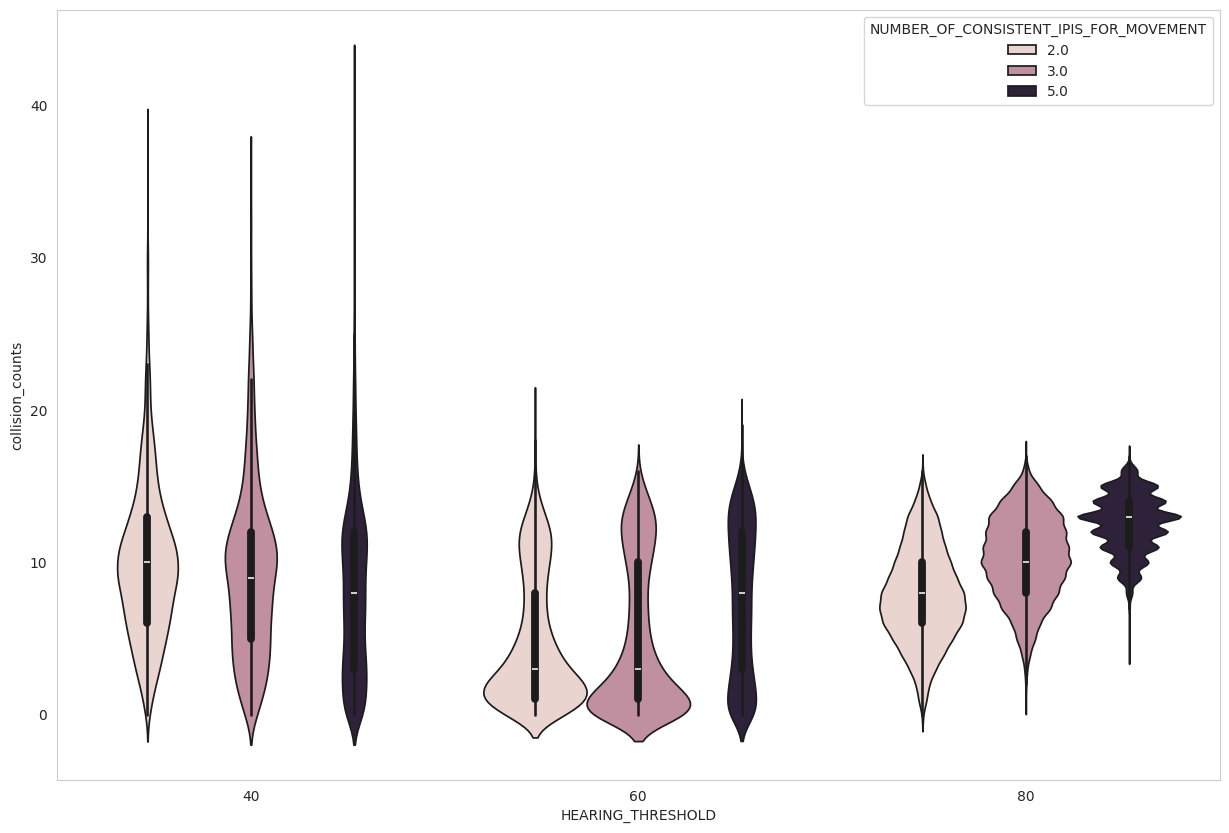

In [5]:
%matplotlib inline
plt.figure(figsize=(15,10))
sns.violinplot(analysis_df[analysis_df["BAT_SPEED"]==3], y="collision_counts", x="HEARING_THRESHOLD", hue="NUMBER_OF_CONSISTENT_IPIS_FOR_MOVEMENT")

In [6]:
from sklearn.decomposition import PCA

<Axes: xlabel='collision_counts', ylabel='space_occupied'>

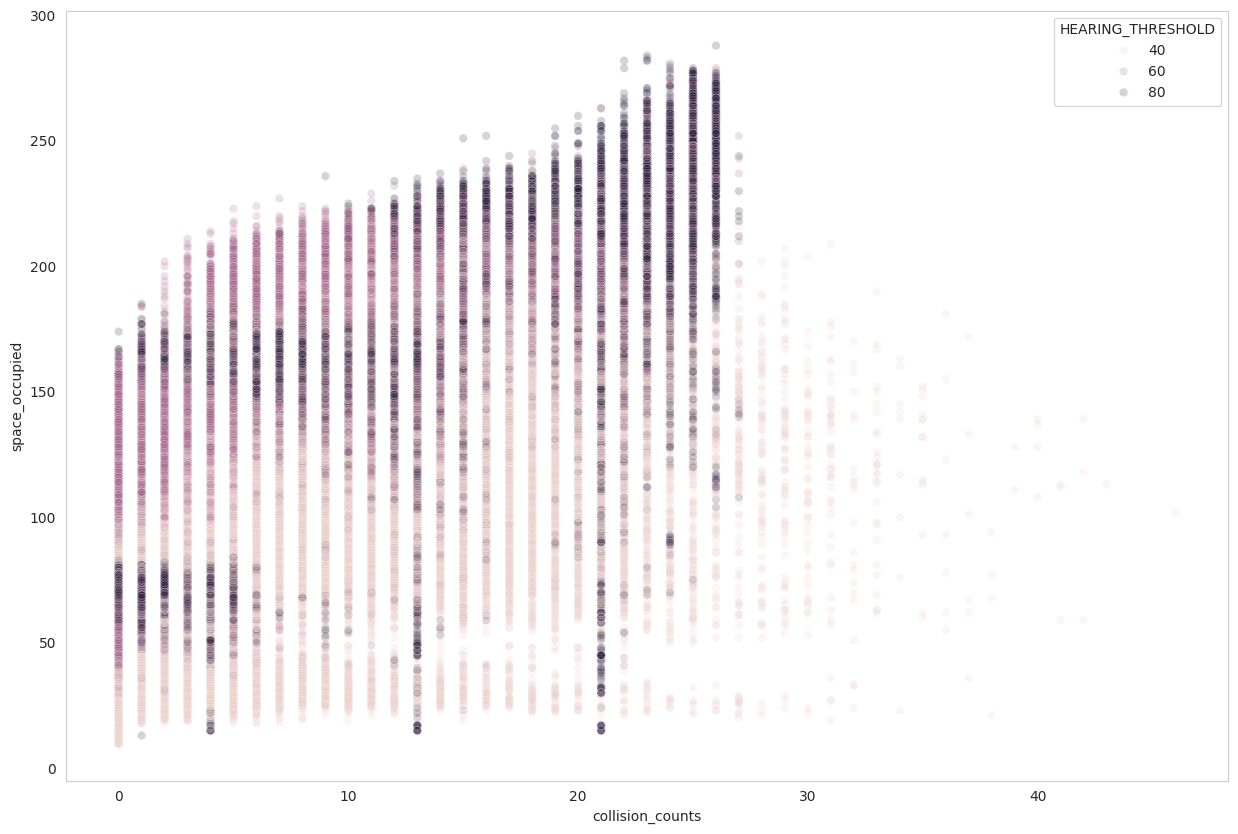

In [7]:
%matplotlib inline
plt.figure(figsize=(15,10))
sns.scatterplot(analysis_df, x="collision_counts", y="space_occupied", hue="HEARING_THRESHOLD", alpha =0.2)

<Axes: xlabel='collision_counts', ylabel='space_occupied'>

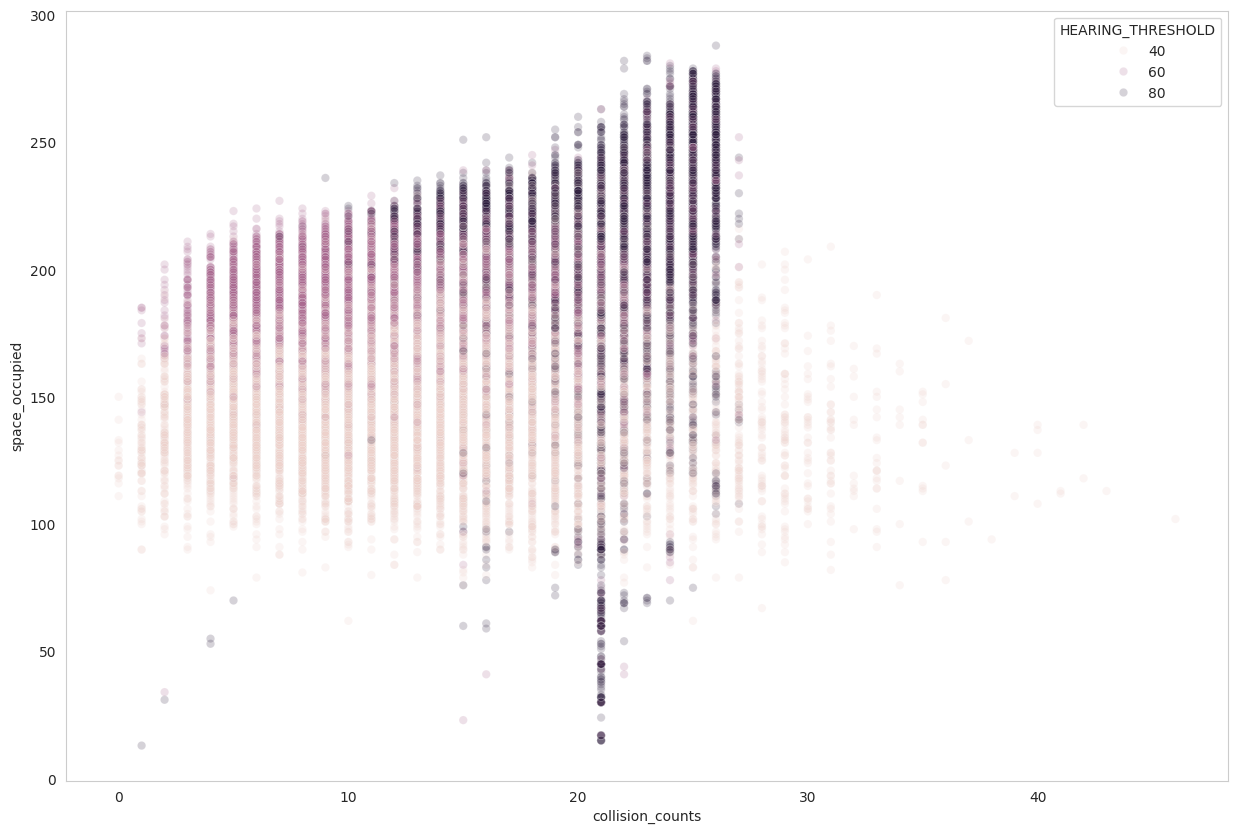

In [8]:
%matplotlib inline
plt.figure(figsize=(15,10))
sns.scatterplot(analysis_df[analysis_df["BAT_SPEED"]==5], x="collision_counts", y="space_occupied", hue="HEARING_THRESHOLD", alpha =0.2)


(200.0, 650.0)

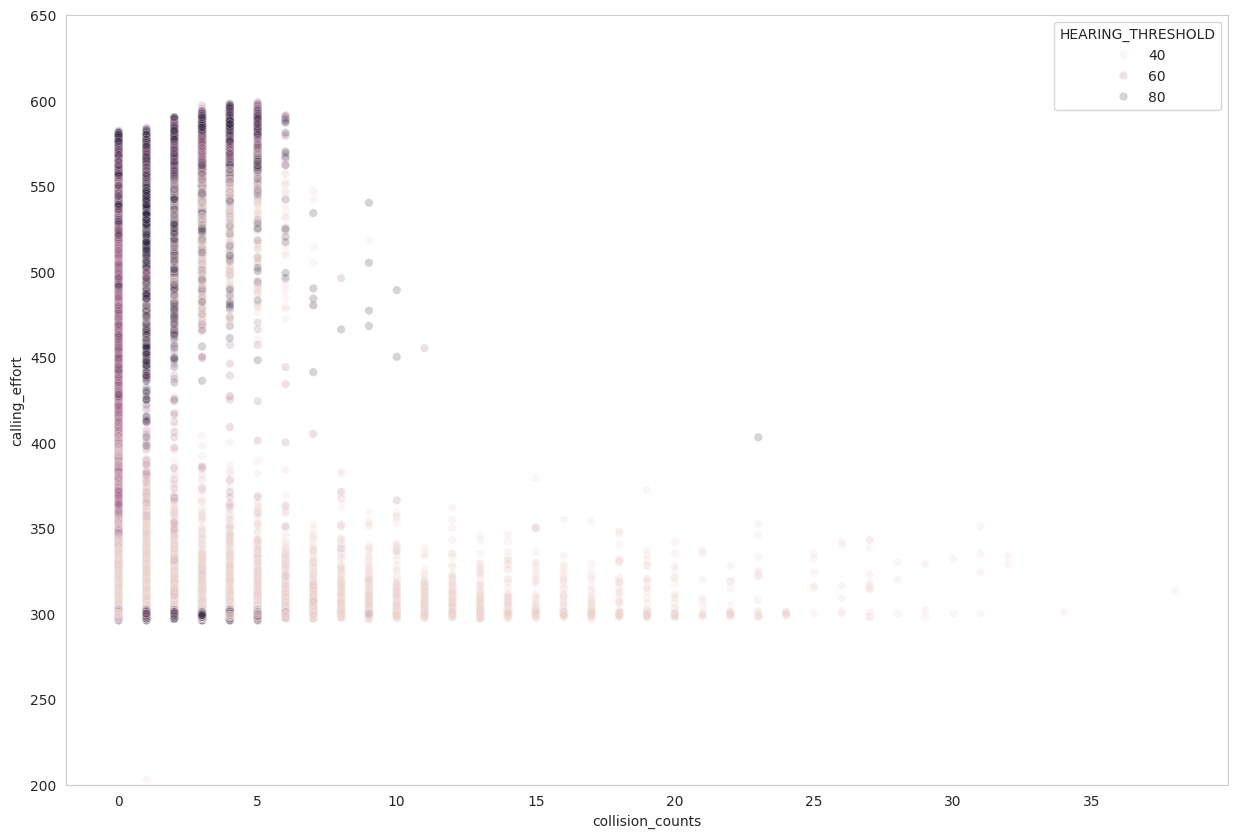

In [9]:
%matplotlib inline
fig = plt.figure(figsize=(15,10))
sns.scatterplot(analysis_df[analysis_df["BAT_SPEED"]==1], x="collision_counts", y="calling_effort", hue="HEARING_THRESHOLD", alpha =0.2)
plt.ylim(200,650)

In [10]:
fig = plt.figure(figsize=(10,10))
ax = Axes3D(fig)
ax.scatter(analysis_df["collision_counts"], analysis_df["calling_effort"], analysis_df["space_occupied"], marker='o')
plt.show()

<Figure size 1000x1000 with 0 Axes>

In [18]:
varying_params = [
    "collision_counts",
    "space_occupied",
    "calling_effort",
    "collision_rate",
    "CALL_DURATION",
    "CALL_RATE_FAST",
    # "EMITTED_SPL",
    "HEARING_THRESHOLD",
    "BAT_SPEED",
    "CALL_DIRECTIONALITY",
    # "HEARING_DIRECTIONALITY",
    # "BAT_ROTATION_SPEED",
    "TEMPORAL_MASKING_FN_TYPE",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    # "BAT_ANGULAR_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
    # "SPATIAL_REFERENCE_FRAME",
    # "JAMMER_RESOLUTION",
]
analysis_df = analysis_df[varying_params]
analysis_df

,collision_counts,space_occupied,calling_effort,collision_rate,CALL_DURATION,CALL_RATE_FAST,HEARING_THRESHOLD,BAT_SPEED,CALL_DIRECTIONALITY,TEMPORAL_MASKING_FN_TYPE,TIME_DELAY_FOR_DIRECTION_CHANGE,BAT_RADIAL_RESOLUTION,MEMORY_WINDOW_FOR_CONSISTENCY,BAT_FRONTAL_RANGE
0,1,66,300,0.008500,0.005,10,80,1,7,full,0.024,0.002,3,60
1,0,67,300,0.000000,0.005,10,80,1,7,full,0.024,0.002,3,60
2,1,60,299,0.008633,0.005,10,80,1,7,full,0.024,0.002,3,60
3,0,69,301,0.000000,0.005,10,80,1,7,full,0.024,0.002,3,60
4,0,67,299,0.000000,0.005,10,80,1,7,full,0.024,0.002,3,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155515,18,183,322,0.040867,0.002,20,40,5,10,full,0.006,0.002,3,60
155516,29,147,320,0.057767,0.002,20,40,5,10,full,0.006,0.002,3,60
155517,17,177,321,0.047533,0.002,20,40,5,10,full,0.006,0.002,3,60
155518,17,166,322,0.043467,0.002,20,40,5,10,full,0.006,0.002,3,60


In [20]:
analysis_df_low_collision_rate = analysis_df[analysis_df["collision_counts"]<=10]
analysis_df_low_collision_rate

,collision_counts,space_occupied,calling_effort,collision_rate,CALL_DURATION,CALL_RATE_FAST,HEARING_THRESHOLD,BAT_SPEED,CALL_DIRECTIONALITY,TEMPORAL_MASKING_FN_TYPE,TIME_DELAY_FOR_DIRECTION_CHANGE,BAT_RADIAL_RESOLUTION,MEMORY_WINDOW_FOR_CONSISTENCY,BAT_FRONTAL_RANGE
0,1,66,300,0.008500,0.005,10,80,1,7,full,0.024,0.002,3,60
1,0,67,300,0.000000,0.005,10,80,1,7,full,0.024,0.002,3,60
2,1,60,299,0.008633,0.005,10,80,1,7,full,0.024,0.002,3,60
3,0,69,301,0.000000,0.005,10,80,1,7,full,0.024,0.002,3,60
4,0,67,299,0.000000,0.005,10,80,1,7,full,0.024,0.002,3,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155496,2,128,362,0.009833,0.002,20,60,3,10,chopped,0.024,0.004,3,30
155497,1,127,358,0.005600,0.002,20,60,3,10,chopped,0.024,0.004,3,30
155498,2,124,357,0.009667,0.002,20,60,3,10,chopped,0.024,0.004,3,30
155499,3,134,384,0.010200,0.002,20,60,3,10,chopped,0.024,0.004,3,30


<Axes: xlabel='collision_counts', ylabel='calling_effort'>

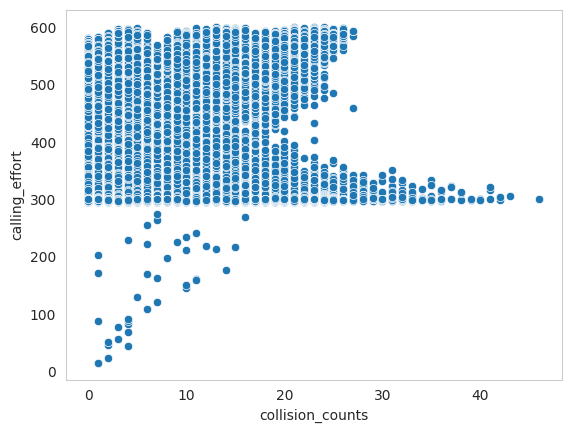

In [22]:
sns.scatterplot(analysis_df, x="collision_counts", y="calling_effort")

In [ ]:
analysis_df[analysis_df["calling_effort"]<200]

,collision_counts,space_occupied,calling_effort,collision_rate,CALL_DURATION,CALL_RATE_FAST,HEARING_THRESHOLD,BAT_SPEED,CALL_DIRECTIONALITY,TEMPORAL_MASKING_FN_TYPE,TIME_DELAY_FOR_DIRECTION_CHANGE,BAT_RADIAL_RESOLUTION,MEMORY_WINDOW_FOR_CONSISTENCY,BAT_FRONTAL_RANGE
2165,4,53,69,0.077732,0.002,20,80,5,10,chopped,0.024,0.002,10,30
4875,4,55,44,0.052009,0.005,10,80,5,7,chopped,0.006,0.004,10,60
7629,6,25,170,0.136032,0.002,20,40,1,7,chopped,0.024,0.002,3,30
17175,6,124,109,0.043843,0.005,10,40,5,7,chopped,0.006,0.004,3,60
33897,2,32,46,0.026043,0.005,10,60,3,10,chopped,0.024,0.004,10,90
36337,8,95,197,0.048515,0.005,10,60,3,7,chopped,0.006,0.002,10,90
40025,1,24,87,0.017196,0.002,10,80,1,7,full,0.006,0.004,10,60
57092,4,54,83,0.033773,0.005,10,80,3,7,chopped,0.024,0.004,10,30
72084,2,31,24,0.040951,0.005,10,80,5,10,full,0.012,0.004,3,90
78464,2,34,51,0.029039,0.002,20,60,5,7,full,0.006,0.004,10,90


In [34]:
analysis_df = pd.read_csv(analysis_data_dir)
analysis_df[analysis_df["calling_effort"]<296]

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,CONVERT_GRIDS+TO_ONE_HOT_?,NUMBER_OF_CONSISTENT_IPIS_FOR_MOVEMENT,TIME_DELAY_THRESHOLD_FOR_REPULSION,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL
2165,5,5,53,4,0.077732,69,iteration_number_5,343,30,0.001,...,yes,5.0,0.024,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3876/,paramset_3876
3222,2,2,128,4,0.044192,229,iteration_number_2,343,30,0.001,...,yes,5.0,0.012,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2518/,paramset_2518
4875,15,15,55,4,0.052009,44,iteration_number_15,343,30,0.001,...,yes,5.0,0.006,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_5686/,paramset_5686
7629,9,9,25,6,0.136032,170,iteration_number_9,343,30,0.001,...,yes,2.0,0.024,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_2034/,paramset_2034
14884,4,4,110,6,0.019300,295,iteration_number_4,343,30,0.001,...,yes,5.0,0.012,consistency,presence,no,1,full,/sensitivity_analysis/paramset_4138/,paramset_4138
17175,15,15,124,6,0.043843,109,iteration_number_15,343,30,0.001,...,yes,2.0,0.006,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_4384/,paramset_4384
19299,19,19,146,7,0.017746,264,iteration_number_19,343,30,0.001,...,yes,2.0,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2494/,paramset_2494
33897,17,17,32,2,0.026043,46,iteration_number_17,343,30,0.001,...,yes,5.0,0.024,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_4967/,paramset_4967
36337,17,17,95,8,0.048515,197,iteration_number_17,343,30,0.001,...,yes,5.0,0.006,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_4814/,paramset_4814
40025,5,5,24,1,0.017196,87,iteration_number_5,343,30,0.001,...,yes,5.0,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_1312/,paramset_1312


there are some error files!!!
check why
also rerun for that param combo
